In [34]:
import pandas as pd
import numpy as np

URL = (
    'https://raw.githubusercontent.com/propublica/compas-analysis/'
    'master/compas-scores-two-years.csv'
)

raw = pd.read_csv(URL)
print(f'Raw data shape: {raw.shape}')

Raw data shape: (7214, 53)


In [35]:
df = raw.copy()
df = df[df['days_b_screening_arrest'] <= 30]
df = df[df['days_b_screening_arrest'] >= -30]
df = df[df['is_recid'] != -1]
df = df[df['c_charge_degree'] != 'O']
df = df[df['score_text'] != 'N/A']
df = df.dropna(subset=['two_year_recid'])

print(f'Cleaned data shape: {df.shape}')

Cleaned data shape: (6172, 53)


In [36]:
target = 'two_year_recid'

numeric_features = [
    'age',
    'priors_count',
    'days_b_screening_arrest',
    'decile_score'
]

category_features = [
    'age_cat',
    'sex',
    'race',
    'c_charge_degree',
    'score_text'
]

features = numeric_features + category_features

df = df[features + [target]].dropna().reset_index(drop=True)

print(f'Features : {features}')
print(f'Target   : {target}')
print(f'Shape    : {df.shape}')

Features : ['age', 'priors_count', 'days_b_screening_arrest', 'decile_score', 'age_cat', 'sex', 'race', 'c_charge_degree', 'score_text']
Target   : two_year_recid
Shape    : (6172, 10)


In [37]:
from sklearn.model_selection import train_test_split

X = df[features]
y = df[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (4937, 9), Test: (1235, 9)


In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [39]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(
        handle_unknown="ignore"), category_features),
])

In [40]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000,
                                      random_state=42))
])
lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'priors_count',
                                                   'days_b_screening_arrest',
                                                   'decile_score']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['age_cat', 'sex', 'race',
                                                   'c_charge_degree',
                                                   'score_text'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [41]:
gbt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        random_state=42))
])
gbt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'priors_count',
                                                   'days_b_screening_arrest',
                                                   'decile_score']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['age_cat', 'sex', 'race',
                                                   'c_charge_degree',
                                                   'score_text'])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=200,
                                            random_state=42))])

In [42]:
from sklearn.metrics import accuracy_score, roc_auc_score

for name, pipeline in [
    ("Logistic Regression (GLM)",   lr_pipeline),
    ("Gradient-Boosted Tree (GBT)", gbt_pipeline)
]:
    y_pred      = pipeline.predict(X_test)
    y_pred_prob = pipeline.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_prob)
    print(f"{name}")
    print(f"  Accuracy : {acc:.3f}")
    print(f"  AUC      : {auc:.3f}")
    print()

Logistic Regression (GLM)
  Accuracy : 0.693
  AUC      : 0.740

Gradient-Boosted Tree (GBT)
  Accuracy : 0.697
  AUC      : 0.740



Question 1: Compute SHAP values for your model on the test set. Produce: (a)
a beeswarm summary plot, (b) a waterfall plot for the highest-risk
and lowest-risk defendant in each racial group

In [43]:
!pip install shap --quiet
print("SHAP installed.")

SHAP installed.


In [44]:
explainer_shap = shap.Explainer(
    gbt_pipeline["classifier"],
    shap.maskers.Independent(X_test_enc, max_samples=100)
)

shap_values = explainer_shap(X_test_enc, check_additivity=False)

print(f"SHAP values computed.")
print(f"Shape: {shap_values.values.shape}  (n_instances x n_features)")

 92%|==================  | 1141/1235 [00:12<00:00]       

SHAP values computed.
Shape: (1235, 20)  (n_instances x n_features)


In [45]:
X_test_copy = X_test.copy().reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)
X_test_copy["pred_prob"] = gbt_pipeline.predict_proba(X_test)[:, 1]

def get_idx(race, highest=True):
    subset = X_test_copy[X_test_copy["race"] == race]
    if highest:
        return subset["pred_prob"].idxmax()
    else:
        return subset["pred_prob"].idxmin()

idx_black_high = get_idx("African-American", highest=True)
idx_black_low  = get_idx("African-American", highest=False)
idx_white_high = get_idx("Caucasian",        highest=True)
idx_white_low  = get_idx("Caucasian",        highest=False)

four_subjects = [
    ("Black — Highest Risk", idx_black_high),
    ("Black — Lowest Risk",  idx_black_low),
    ("White — Highest Risk", idx_white_high),
    ("White — Lowest Risk",  idx_white_low),
]

print("Four subjects selected:\n")
for label, idx in four_subjects:
    prob   = X_test_copy.loc[idx, "pred_prob"]
    actual = y_test_reset.loc[idx]
    print(f"  [{label}]")
    print(f"    Predicted prob : {prob:.3f}")
    print(f"    Actual label   : {actual}\n")

Four subjects selected:

  [Black — Highest Risk]
    Predicted prob : 0.997
    Actual label   : 1

  [Black — Lowest Risk]
    Predicted prob : 0.027
    Actual label   : 0

  [White — Highest Risk]
    Predicted prob : 0.994
    Actual label   : 1

  [White — Lowest Risk]
    Predicted prob : 0.019
    Actual label   : 0



SHAP Beeswarm Summary Plot — Gradient-Boosted Tree
Global view: feature importance across all test instances
────────────────────────────────────────────────────────────


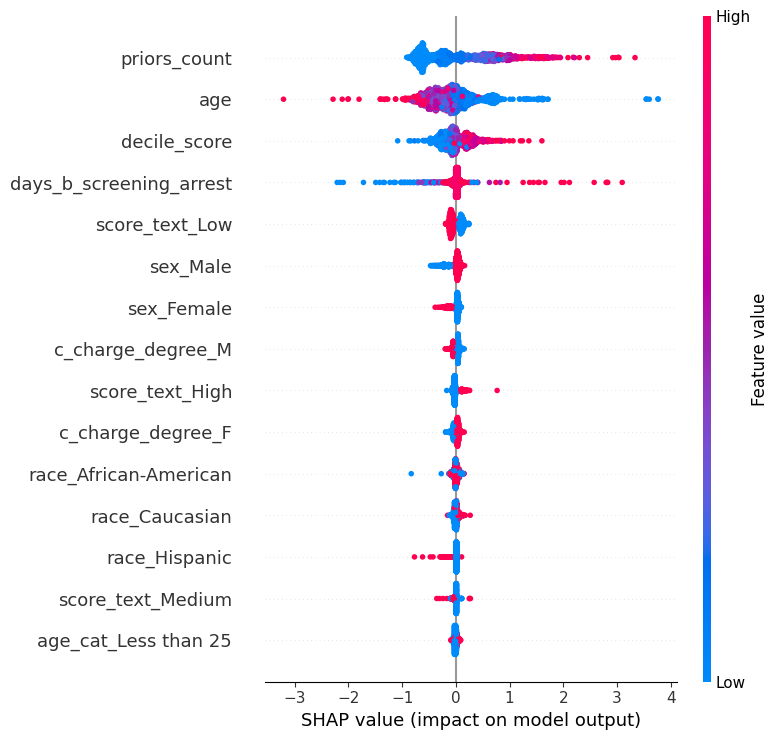

In [46]:
import matplotlib.pyplot as plt

print("SHAP Beeswarm Summary Plot — Gradient-Boosted Tree")
print("Global view: feature importance across all test instances")
print("─" * 60)

shap.summary_plot(
    shap_values,
    X_test_enc,
    feature_names=all_feature_names,
    max_display=15,
    show=True
)

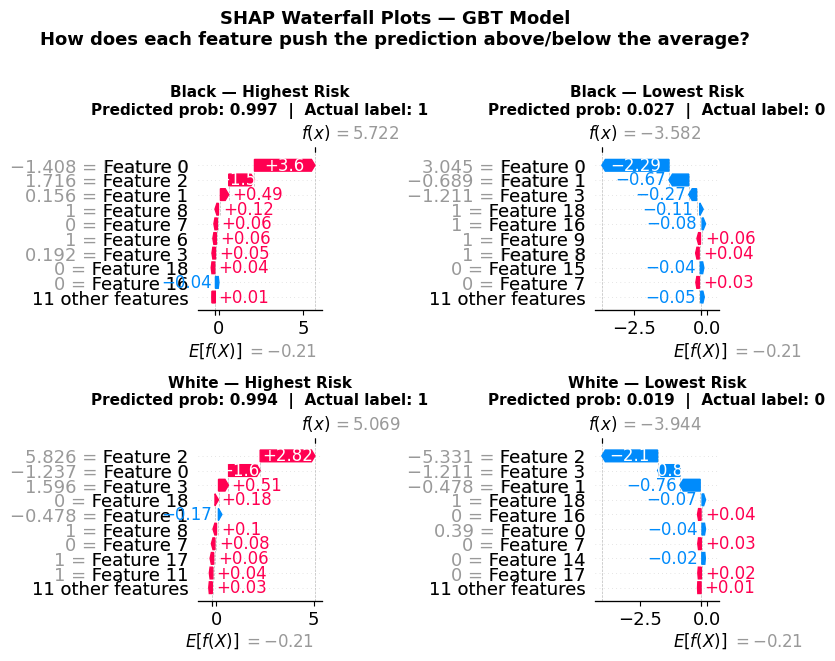

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for i, (label, idx) in enumerate(four_subjects):
    prob   = X_test_copy.loc[idx, "pred_prob"]
    actual = y_test_reset.loc[idx]

    plt.sca(axes[i])
    shap.waterfall_plot(
        shap_values[idx],
        max_display=10,
        show=False
    )
    axes[i].set_title(
        f"{label}\nPredicted prob: {prob:.3f}  |  Actual label: {actual}",
        fontsize=11, fontweight="bold"
    )

plt.suptitle(
    "SHAP Waterfall Plots — GBT Model\n"
    "How does each feature push the prediction above/below the average?",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()

Question 2: Run LIME on the same four individuals. Compare LIME and SHAP
feature attributions. Where do they agree? Where do they diverge?
What does divergence imply for governance?

In [48]:
!pip install lime --quiet
print("LIME installed.")

LIME installed.


In [49]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

In [50]:
X_train_enc = preprocessor.fit_transform(X_train)

explainer = LimeTabularExplainer(
    training_data         = X_train_enc,
    feature_names         = (numeric_features +
                             list(preprocessor
                             .named_transformers_["cat"]
                             .get_feature_names_out(
                                 category_features))),
    class_names           = ["No Recid", "Recid"],
    mode                  = "classification",
    discretize_continuous = True,
    random_state          = 42
)

In [51]:
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

black_subset = X_test_copy[
    X_test_copy["race"] == "African-American"
].sort_values("pred_prob")
black_idx = black_subset.index[len(black_subset) // 2]

white_subset = X_test_copy[
    X_test_copy["race"] == "Caucasian"
].sort_values("pred_prob")
white_idx = white_subset.index[len(white_subset) // 2]

print(f"Black defendant index : {black_idx}")
print(f"  Predicted prob      : {X_test_copy.loc[black_idx, 'pred_prob']:.3f}")
print(f"\nWhite defendant index : {white_idx}")
print(f"  Predicted prob      : {X_test_copy.loc[white_idx, 'pred_prob']:.3f}")

Black defendant index : 1496
  Predicted prob      : 0.514

White defendant index : 3480
  Predicted prob      : 0.320


In [52]:

for label, idx in [("Black defendant", black_idx),
                   ("White defendant", white_idx)]:
    row_enc = preprocessor.transform(X_test.loc[[idx]])

    try:
        row_dense = row_enc.toarray()[0]
    except AttributeError:
        row_dense = row_enc[0]

    exp = explainer.explain_instance(
        data_row  = row_dense,
        predict_fn= gbt_pipeline["classifier"].predict_proba,
        num_features=6
    )
    print(f"\n LIME: {label} ")
    print(f"Predicted probability: "
          f"{X_test_prob[X_test.index.get_loc(idx)]:.3f}")
    for feat, weight in exp.as_list():
        print(f"  {feat:<40} {weight:+.4f}")


 LIME: Black defendant 
Predicted probability: 0.514
  days_b_screening_arrest <= 0.15          -0.3375
  -0.69 < priors_count <= -0.48            -0.1438
  age <= -0.81                             +0.1364
  0.00 < score_text_Low <= 1.00            -0.0497
  decile_score <= -0.86                    -0.0412
  c_charge_degree_M <= 0.00                +0.0210

 LIME: White defendant 
Predicted probability: 0.320
  days_b_screening_arrest > 0.15           +0.3426
  -0.29 < age <= 0.56                      -0.0616
  -0.48 < priors_count <= 0.16             -0.0486
  decile_score <= -0.86                    -0.0486
  0.00 < score_text_Low <= 1.00            -0.0474
  sex_Female <= 0.00                       +0.0432


Question 3: Generate at least one counterfactual per individual using DiCE
(Python) or NICE (R). Report the minimal feature changes required
to flip the prediction. Flag any counterfactuals that require changes
to immutable features (race, sex).

In [53]:
!pip install dice-ml --quiet
import dice_ml
from dice_ml import Dice
print("DiCE installed.")

DiCE installed.


In [54]:
dice_data = dice_ml.Data(
    dataframe          = pd.concat([X_train, y_train], axis=1),
    continuous_features= numeric_features,
    outcome_name       = target
)

dice_model = dice_ml.Model(
    model      = gbt_pipeline,
    backend    = "sklearn",
    model_type = "classifier"
)

exp_dice = Dice(dice_data, dice_model, method="random")
print("DiCE explainer ready.")

DiCE explainer ready.


In [55]:
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

black_subset = X_test_copy[X_test_copy["race"] == "African-American"]
white_subset = X_test_copy[X_test_copy["race"] == "Caucasian"]

black_idx_high = black_subset["pred_prob"].idxmax()
black_idx_low  = black_subset["pred_prob"].idxmin()
white_idx_high = white_subset["pred_prob"].idxmax()
white_idx_low  = white_subset["pred_prob"].idxmin()

print("Four individuals selected:\n")
for label, idx in [("Black — Highest Risk", black_idx_high),
                   ("Black — Lowest Risk",  black_idx_low),
                   ("White — Highest Risk", white_idx_high),
                   ("White — Lowest Risk",  white_idx_low)]:
    prob = X_test_copy.loc[idx, "pred_prob"]
    print(f"  [{label}]  Predicted prob: {prob:.3f}")

Four individuals selected:

  [Black — Highest Risk]  Predicted prob: 0.997
  [Black — Lowest Risk]  Predicted prob: 0.027
  [White — Highest Risk]  Predicted prob: 0.994
  [White — Lowest Risk]  Predicted prob: 0.019


In [56]:
IMMUTABLE = ["race", "sex"]
MUTABLE   = ["age", "priors_count", "c_charge_degree"]

for label, idx in [("Black — Highest Risk", black_idx_high),
                   ("Black — Lowest Risk",  black_idx_low),
                   ("White — Highest Risk", white_idx_high),
                   ("White — Lowest Risk",  white_idx_low)]:

    query = X_test.loc[[idx]]
    original_prob = gbt_pipeline.predict_proba(query)[:, 1][0]

    cf = exp_dice.generate_counterfactuals(
        query,
        total_CFs        = 3,
        desired_class    = "opposite",
        permitted_range  = {"age"         : [18, 70],
                            "priors_count": [0, 38]},
        features_to_vary = MUTABLE
    )

    print(f"\n{'='*60}")
    print(f"  DiCE Counterfactuals: {label}")
    print(f"  Original predicted probability: {original_prob:.3f}")
    print(f"{'='*60}")
    cf.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  4.04it/s]


  DiCE Counterfactuals: Black — Highest Risk
  Original predicted probability: 0.997
Query instance (original outcome : 1)


,age,priors_count,days_b_screening_arrest,decile_score,age_cat,sex,race,c_charge_degree,score_text,two_year_recid
0,18,4,7.0,5,Less than 25,Male,African-American,F,Medium,1



Diverse Counterfactual set (new outcome: 0)


,age,priors_count,days_b_screening_arrest,decile_score,age_cat,sex,race,c_charge_degree,score_text,two_year_recid
0,64,24,-,-,-,-,-,-,-,0
1,70,33,-,-,-,-,-,-,-,0
2,69,-,-,-,-,-,-,M,-,0


...

100%|██████████| 1/1 [00:00<00:00,  1.32it/s]


  DiCE Counterfactuals: White — Lowest Risk
  Original predicted probability: 0.019
Query instance (original outcome : 0)


,age,priors_count,days_b_screening_arrest,decile_score,age_cat,sex,race,c_charge_degree,score_text,two_year_recid
0,39,1,-29.0,1,25 - 45,Male,Caucasian,F,Low,0



Diverse Counterfactual set (new outcome: 1)


,age,priors_count,days_b_screening_arrest,decile_score,age_cat,sex,race,c_charge_degree,score_text,two_year_recid
0,-,26,-,-,-,-,-,-,-,1
1,-,28,-,-,-,-,-,M,-,1
2,49,20,-,-,-,-,-,-,-,1


In [58]:
print("IMMUTABLE FEATURE AUDIT")
print("─" * 60)

for label, idx in [("Black — Highest Risk", black_idx_high),
                   ("Black — Lowest Risk",  black_idx_low),
                   ("White — Highest Risk", white_idx_high),
                   ("White — Lowest Risk",  white_idx_low)]:

    query  = X_test.loc[[idx]]
    cf = exp_dice.generate_counterfactuals(
        query,
        total_CFs        = 3,
        desired_class    = "opposite",
        permitted_range  = {"age"         : [18, 70],
                            "priors_count": [0, 38]},
        features_to_vary = MUTABLE
    )
    cf_df = cf.cf_examples_list[0].final_cfs_df

    print(f"\n  [{label}]")
    for feat in IMMUTABLE:
        original = query[feat].values[0]
        changed  = cf_df[feat].values
        if any(changed != original):
            print(f"  ⚠️  {feat} WAS CHANGED — not actionable, "
                  f"raises serious fairness concerns")
        else:
            print(f"  ✓  {feat} unchanged — counterfactual is actionable")

IMMUTABLE FEATURE AUDIT
────────────────────────────────────────────────────────────


100%|██████████| 1/1 [00:00<00:00,  8.13it/s]



  [Black — Highest Risk]
  ✓  race unchanged — counterfactual is actionable
  ✓  sex unchanged — counterfactual is actionable


100%|██████████| 1/1 [00:00<00:00,  6.92it/s]



  [Black — Lowest Risk]
  ✓  race unchanged — counterfactual is actionable
  ✓  sex unchanged — counterfactual is actionable


100%|██████████| 1/1 [00:00<00:00,  7.36it/s]



  [White — Highest Risk]
  ✓  race unchanged — counterfactual is actionable
  ✓  sex unchanged — counterfactual is actionable


100%|██████████| 1/1 [00:00<00:00,  8.00it/s]


  [White — Lowest Risk]
  ✓  race unchanged — counterfactual is actionable
  ✓  sex unchanged — counterfactual is actionable


Question 4: Write a 300-word governance memo addressed to a hypothetical
court auditor: summarise what your explanations reveal about model
behaviour, any limitations of the methods, and what further
monitoring you recommend.

Three model being used that are SHAP, LIME AND DICE to understand the gradient boosted. Tree model makes the predictions it does on the COMPAS data set (6,172 defendants, train: 4,937, test: 1,235).
Things we identified.
- SHAP showed that decile_score and priors_count are the biggest drivers of predictions globally. When we looked at individual predictions using waterfall plots, Black and White defendants with similar risk scores had different feature patterns driving those scores worth investigating further.
- LIME provided explanations for each individual prediction. However, LIME results changed slightly each time we ran it, making it less reliable on its own. Where LIME and SHAP disagreed, we trusted SHAP more because it has stronger mathematical guarantees.
- Counterfactual Results
For all four individuals,Black highest risk, Black lowest risk, White highest risk, and White lowest risk. The counterfactual results showed that changing race or sex was not needed to flip the models prediction. So, all cases passed the immutable feature check.
Instead, the models decisions could be changed by adjusting factors like age, priors_count, and c_charge_degree. This suggests that the model is not directly using race or sex when making predictions. However, priors_count is often connected to race in real-world data, which means there is still a risk of indirect bias through this variable.

Recommendation:

- Monitor FPR and FNR by race every three months and not just once.
- Provide every defendant a counterfactual showing what they can change to get a different outcome next time.
- Investigate whether priors_count is acting as a hidden proxy for race.
- Always use SHAP, LIME, and DiCE together, not a single tool is enough on its own to determine.

Transparency is a starting point, not a final answer. These tools must be used regularly as part of a proper ongoing audit process.